# ERA5 Hourly Total Precipitation — Italy
## Data Inspection → Annual Maxima → GEV Fitting → Return-Period Maps

**Data:** ERA5 reanalysis, hourly accumulated `tp` (m), 0.25° grid, Italy domain (lat 35–48°N, lon 6–19°E)  
**Period:** 1995–2026 (June), split across four GRIB files  
**Goal:** pixel-wise GEV fitting on annual maxima → RP maps for durations 1 h, 3 h, 6 h, 12 h, 24 h

---

## 0 · Imports & paths

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os, gc
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from scipy.stats import genextreme as gev
from scipy.stats import kstest
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from tqdm.auto import tqdm

# ── paths ──────────────────────────────────────────────────────────────────
DATA_DIR  = "/home/admin_climatecharted_com/data/ERA5_tp_hourly"
SHP_PATH  = "/home/admin_climatecharted_com/data/it_4326/it_4326.shp"
OUT_DIR   = "/home/admin_climatecharted_com/outputs/ERA5_GEV"
os.makedirs(OUT_DIR, exist_ok=True)

GRIB_FILES = [
    os.path.join(DATA_DIR, "ERA5_TP_ITA_1995-2004.grib"),
    os.path.join(DATA_DIR, "ERA5_TP_ITA_2005-2014.grib"),
    os.path.join(DATA_DIR, "ERA5_TP_ITA_2015-2025.grib"),
    os.path.join(DATA_DIR, "ERA5_TP_ITA_2025-2026.grib"),
]

# Accumulation durations (hours) for which RP maps will be produced
DURATIONS_H = [1, 3, 6, 12, 24]

# Return periods (years)
RETURN_PERIODS = [2, 5, 10, 25, 50, 100, 200]

# GEV shape cap (prevents heavy-tail instability on short records)
C_MIN = -0.5

print("Imports OK")

Imports OK


---
## 1 · Data inspection (single file first)

Before loading everything we inspect one file thoroughly.

In [2]:
# ── 1.1  Open one file and examine structure ────────────────────────────────
sample_path = GRIB_FILES[1]   # 2005-2014
ds_s = xr.open_dataset(sample_path, engine="cfgrib")

print("=" * 60)
print("Dataset overview")
print("=" * 60)
print(ds_s)
print()

print("--- tp variable attributes ---")
for k, v in ds_s.tp.attrs.items():
    print(f"  {k}: {v}")

print()
print(f"time  : {ds_s.time.min().values} → {ds_s.time.max().values}  ({ds_s.dims['time']} records)")
print(f"step  : {ds_s.step.values}")
print(f"lat   : {float(ds_s.latitude.min()):.2f} → {float(ds_s.latitude.max()):.2f}  (n={ds_s.dims['latitude']})")
print(f"lon   : {float(ds_s.longitude.min()):.2f} → {float(ds_s.longitude.max()):.2f}  (n={ds_s.dims['longitude']})")
print(f"tp unit: {ds_s.tp.attrs.get('units', 'unknown')}  (multiply ×1000 for mm)")
print(f"tp dtype: {ds_s.tp.dtype}")

Dataset overview
<xarray.Dataset> Size: 986MB
Dimensions:     (time: 7305, step: 12, latitude: 53, longitude: 53)
Coordinates:
  * time        (time) datetime64[ns] 58kB 2004-12-31T18:00:00 ... 2014-12-31...
  * step        (step) timedelta64[ns] 96B 01:00:00 02:00:00 ... 12:00:00
    valid_time  (time, step) datetime64[ns] 701kB ...
  * latitude    (latitude) float64 424B 48.0 47.75 47.5 ... 35.5 35.25 35.0
  * longitude   (longitude) float64 424B 6.0 6.25 6.5 6.75 ... 18.5 18.75 19.0
    number      int64 8B ...
    surface     float64 8B ...
Data variables:
    tp          (time, step, latitude, longitude) float32 985MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-05T13:41 GRIB to CDM+CF 

In [3]:
# ── 1.2  Value range and missingness ────────────────────────────────────────
tp_s = ds_s.tp * 1000  # → mm

print("--- Value statistics (mm) ---")
vals = tp_s.values
print(f"  min      : {np.nanmin(vals):.4f} mm")
print(f"  max      : {np.nanmax(vals):.4f} mm")
print(f"  mean     : {np.nanmean(vals):.4f} mm")
print(f"  NaN count: {np.isnan(vals).sum()} / {vals.size} ({100*np.isnan(vals).mean():.2f}%)")
print(f"  Negative : {(vals < 0).sum()} cells  (ERA5 can have tiny negatives due to spectral truncation)")

print()
print("--- Step-by-step max (mm) — check for double-peak artefact ---")
for i, s in enumerate(ds_s.step.values):
    h = int(pd.to_timedelta(s).total_seconds() // 3600)
    mx = float(tp_s.isel(step=i).max())
    print(f"  step +{h:02d}h : max = {mx:.3f} mm")

--- Value statistics (mm) ---
  min      : 0.0000 mm
  max      : 29.9344 mm
  mean     : 0.0984 mm
  NaN count: 33708 / 246236940 (0.01%)
  Negative : 0 cells  (ERA5 can have tiny negatives due to spectral truncation)

--- Step-by-step max (mm) — check for double-peak artefact ---
  step +01h : max = 27.192 mm
  step +02h : max = 25.739 mm
  step +03h : max = 26.450 mm
  step +04h : max = 19.274 mm
  step +05h : max = 23.611 mm
  step +06h : max = 22.071 mm
  step +07h : max = 23.709 mm
  step +08h : max = 23.816 mm
  step +09h : max = 27.003 mm
  step +10h : max = 29.934 mm
  step +11h : max = 28.183 mm
  step +12h : max = 24.307 mm


In [4]:
# ── 1.3  Understand the time/step accumulation structure ────────────────────
#
#  ERA5 hourly GRIB (CDS download via forecast accumulation):
#   - Each 'time' is a forecast base-time (typically 06Z or 18Z).
#   - 'step' goes 1h, 2h, … 12h — these are CUMULATIVE accumulations
#     from the base-time within that forecast leg.
#   - To get INCREMENTAL (true hourly) precipitation:
#       P(step=Nh) = accum(Nh) - accum((N-1)h)      for N ≥ 2
#       P(step=1h) = accum(1h)                        (no previous step)
#
#  This is the well-known ERA5 "two-forecast-legs" (06Z + 18Z) structure.
#  See: https://confluence.ecmwf.int/x/Lp3mD

print("Base-times present (first 10):")
print(ds_s.time.values[:10])

# Verify: consecutive base-times differ by 12h (06Z→18Z or 18Z→06Z+1day)
base_times = pd.to_datetime(ds_s.time.values)
diffs = base_times[1:] - base_times[:-1]
print()
print("Diffs between base-times (expected 12h):")
print(pd.Series(diffs).value_counts())

# Verify 'step' dimension
print()
print("Step values (should be 1h…12h):")
steps_h = [int(pd.to_timedelta(s).total_seconds()//3600) for s in ds_s.step.values]
print(steps_h)

Base-times present (first 10):
['2004-12-31T18:00:00.000000000' '2005-01-01T06:00:00.000000000'
 '2005-01-01T18:00:00.000000000' '2005-01-02T06:00:00.000000000'
 '2005-01-02T18:00:00.000000000' '2005-01-03T06:00:00.000000000'
 '2005-01-03T18:00:00.000000000' '2005-01-04T06:00:00.000000000'
 '2005-01-04T18:00:00.000000000' '2005-01-05T06:00:00.000000000']

Diffs between base-times (expected 12h):
0 days 12:00:00    7304
Name: count, dtype: int64

Step values (should be 1h…12h):
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


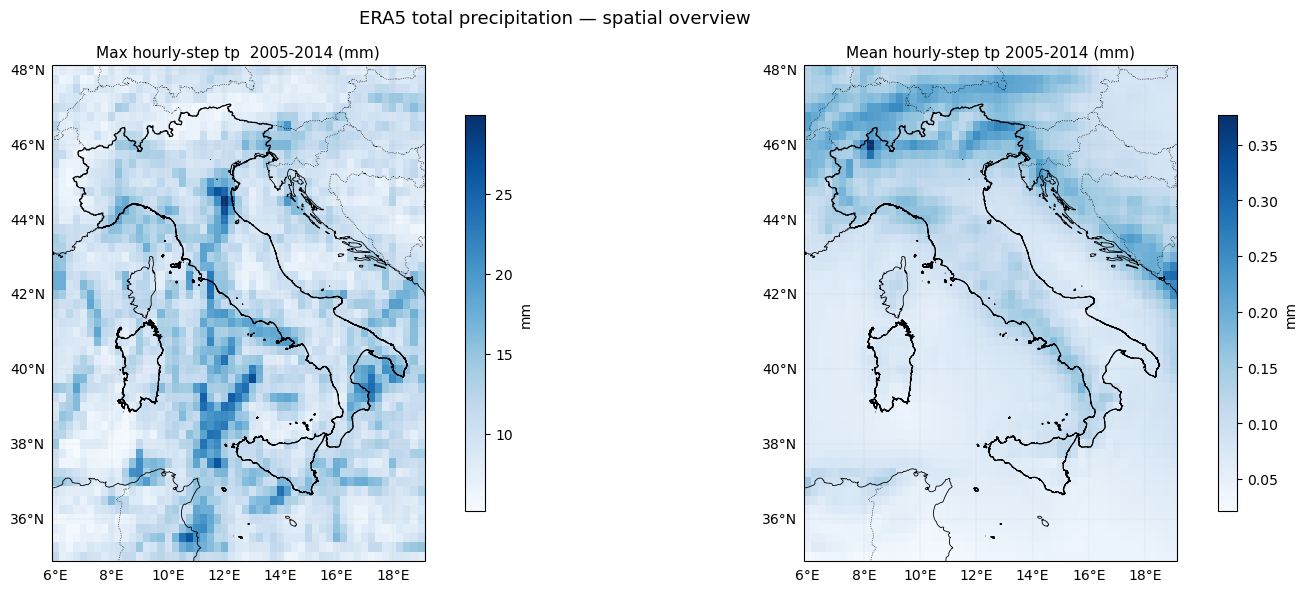

In [5]:
# ── 1.4  Visual inspection: spatial maps ────────────────────────────────────
tp_mm_s = ds_s.tp * 1000
max_rain = tp_mm_s.max(dim=["time", "step"])
mean_rain = tp_mm_s.mean(dim=["time", "step"])

try:
    ita = gpd.read_file(SHP_PATH)
    has_shp = True
except Exception:
    has_shp = False
    print("Shapefile not found — plots without overlay")

def base_map_ax(fig, pos, title, cmap, data, label, vmin=None, vmax=None):
    ax = fig.add_subplot(pos, projection=ccrs.PlateCarree())
    im = ax.pcolormesh(
        data.longitude, data.latitude, data.values,
        cmap=cmap, transform=ccrs.PlateCarree(),
        vmin=vmin, vmax=vmax
    )
    ax.coastlines(resolution="10m", linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    if has_shp:
        ita.boundary.plot(ax=ax, edgecolor="k", linewidth=0.8, transform=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.5)
    gl.top_labels = gl.right_labels = False
    plt.colorbar(im, ax=ax, label=label, shrink=0.8)
    ax.set_title(title, fontsize=11)
    return ax

fig = plt.figure(figsize=(16, 6))
base_map_ax(fig, 121, "Max hourly-step tp  2005-2014 (mm)", "Blues", max_rain, "mm")
base_map_ax(fig, 122, "Mean hourly-step tp 2005-2014 (mm)", "Blues", mean_rain, "mm")
plt.suptitle("ERA5 total precipitation — spatial overview", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "00_spatial_overview.png"), dpi=150)
plt.show()

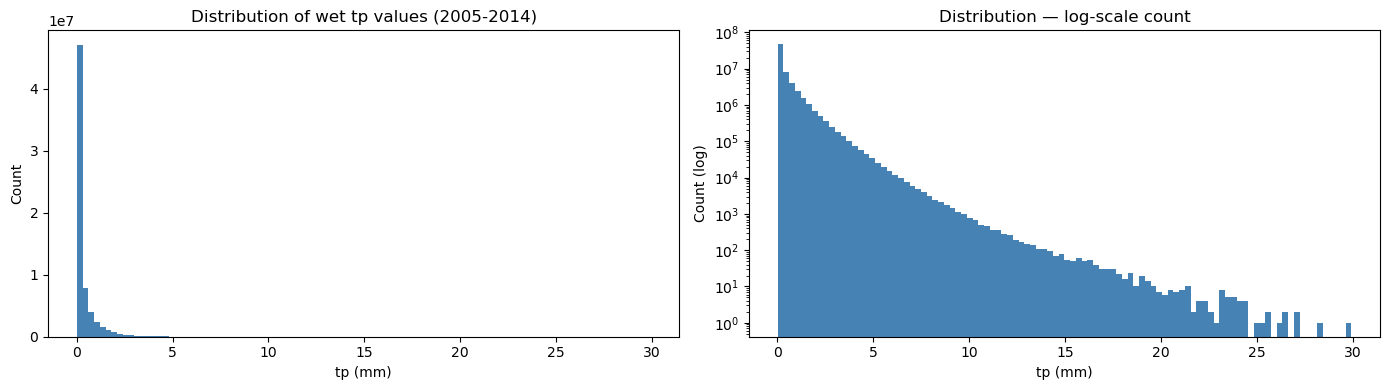

Percentiles of wet (>0.01 mm) values:
  p 50.0 = 0.113 mm
  p 90.0 = 1.004 mm
  p 95.0 = 1.573 mm
  p 99.0 = 3.139 mm
  p 99.9 = 5.902 mm
  p100.0 = 29.934 mm


11492

In [6]:
# ── 1.5  Value histogram ─────────────────────────────────────────────────────
vals_flat = tp_mm_s.values.ravel()
vals_pos  = vals_flat[vals_flat > 0.01]   # exclude dry (< 0.01 mm)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(vals_pos, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("tp (mm)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of wet tp values (2005-2014)")

axes[1].hist(vals_pos, bins=100, color="steelblue", edgecolor="none", log=True)
axes[1].set_xlabel("tp (mm)")
axes[1].set_ylabel("Count (log)")
axes[1].set_title("Distribution — log-scale count")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "01_histogram.png"), dpi=150)
plt.show()

print(f"Percentiles of wet (>0.01 mm) values:")
for p in [50, 90, 95, 99, 99.9, 100]:
    print(f"  p{p:5.1f} = {np.percentile(vals_pos, p):.3f} mm")

del ds_s, tp_mm_s, max_rain, mean_rain, vals_flat, vals_pos
gc.collect()

---
## 2 · Load & flatten all files

### Key concept: incremental hourly precipitation

ERA5 stores **cumulative** accumulations within each 12-h forecast leg (steps 1h–12h from base-time 06Z and 18Z).  
To reconstruct true hourly amounts we take **first differences along the step axis** (step[n] − step[n−1]).  
After differencing we assign each value its `valid_time = base_time + step`.  
This produces a clean, non-overlapping hourly time series at every grid point.

In [7]:
def open_grib(path):
    """Open one ERA5 GRIB file with cfgrib."""
    return xr.open_dataset(path, engine="cfgrib", decode_timedelta=True)


def incremental_from_accumulation(da):
    """
    Convert cumulative-within-leg accumulation (time × step) to
    incremental hourly values, then stack to a 1-D valid_time axis.

    Parameters
    ----------
    da : xr.DataArray  shape (time, step, lat, lon), units = metres

    Returns
    -------
    xr.DataArray  shape (valid_time, lat, lon), units = mm
    """
    # 1.  Compute incremental amounts along step axis
    #     step=1h  → value unchanged (first step of leg, no prior)
    #     step=Nh  → accum(Nh) - accum((N-1)h)
    da_diff = da.diff(dim="step")                      # shape: (time, step-1, lat, lon)
    da_first = da.isel(step=0).expand_dims("step", axis=1)  # first step of each leg
    da_incr = xr.concat([da_first, da_diff], dim="step")
    da_incr["step"] = da["step"]                       # restore step coords

    # Clip tiny negatives (spectral truncation artefacts in ERA5)
    da_incr = da_incr.clip(min=0)

    # 2.  Convert m → mm
    da_incr = da_incr * 1000

    # 3.  Build valid_time = base_time + step
    if "valid_time" not in da_incr.coords:
        vt = da_incr.time.values[:, None] + da_incr.step.values[None, :]
        da_incr = da_incr.assign_coords(valid_time=(("time", "step"), vt))

    # 4.  Stack (time, step) → valid_time
    da_flat = da_incr.stack(valid_time=("time", "step"))
    vt_vals = da_flat.valid_time.values.ravel()
    da_flat = da_flat.drop_vars(["time", "step", "valid_time"], errors="ignore")
    da_flat = da_flat.assign_coords(valid_time=("valid_time", pd.to_datetime(vt_vals)))
    da_flat = da_flat.rename({"valid_time": "time"})
    da_flat = da_flat.sortby("time")
    da_flat = da_flat.drop_vars(["number", "surface"], errors="ignore")

    return da_flat.transpose("time", "latitude", "longitude")


print("Functions defined.")

Functions defined.


In [8]:
# ── 2.1  Process each GRIB and collect hourly DataArrays ────────────────────
#
# For the last file (2025-2026) we clip to ≤ 2026-06-01 to avoid
# incomplete months affecting annual-maxima for 2026.

FILE_SLICES = {
    GRIB_FILES[0]: ("1995-01-01", "2004-12-31"),
    GRIB_FILES[1]: ("2005-01-01", "2014-12-31"),
    GRIB_FILES[2]: ("2015-01-01", "2025-12-31"),
    GRIB_FILES[3]: ("2025-01-01", "2026-06-01"),   # tail file
}

chunks_list = []

for fpath, (t0, t1) in FILE_SLICES.items():
    fname = os.path.basename(fpath)
    print(f"Loading {fname} ...")
    ds_f = open_grib(fpath)
    da   = ds_f.tp
    da_h = incremental_from_accumulation(da)
    da_h = da_h.sel(time=slice(t0, t1))
    # Drop duplicates that may appear at the boundary between files
    _, idx = np.unique(da_h.time.values, return_index=True)
    da_h = da_h.isel(time=idx)
    print(f"  → {len(da_h.time)} hourly steps  [{pd.Timestamp(da_h.time.values[0])} → {pd.Timestamp(da_h.time.values[-1])}]")
    chunks_list.append(da_h)
    ds_f.close()

print("\nConcatenating along time...")
tp_hourly = xr.concat(chunks_list, dim="time")

# Final deduplication across file boundaries
_, idx = np.unique(tp_hourly.time.values, return_index=True)
tp_hourly = tp_hourly.isel(time=idx)
tp_hourly = tp_hourly.sortby("time")

print(f"\nFull hourly dataset: {tp_hourly.dims}")
print(f"Time range: {pd.Timestamp(tp_hourly.time.values[0])} → {pd.Timestamp(tp_hourly.time.values[-1])}")
print(f"Shape     : {tp_hourly.shape}")
print(f"Memory    : {tp_hourly.nbytes / 1e9:.2f} GB")

Loading ERA5_TP_ITA_1995-2004.grib ...


TypeError: <class 'tuple'> is not convertible to datetime

---
## 3 · Full data inspection (combined series)

In [ ]:
# ── 3.1  NaN / missing-value audit ──────────────────────────────────────────
nan_mask    = np.isnan(tp_hourly.values)
total_cells = tp_hourly.size

print("=" * 55)
print("NaN / missing-value summary")
print("=" * 55)
print(f"  Total cells          : {total_cells:>15,}")
print(f"  NaN cells            : {nan_mask.sum():>15,}  ({100*nan_mask.mean():.3f}%)")

# Pixels that are ALWAYS NaN (i.e. outside domain or sea pixels)
always_nan  = nan_mask.all(axis=0)
print(f"  Always-NaN pixels    : {always_nan.sum():>15,}")

# Timesteps with ALL pixels NaN
all_nan_t   = nan_mask.all(axis=(1, 2))
print(f"  Timesteps fully NaN  : {all_nan_t.sum():>15,}")

# Negative values (should be 0 after clip, but confirm)
neg_cells   = (tp_hourly.values < 0).sum()
print(f"  Negative cells       : {neg_cells:>15,}  (should be 0 after clip)")

print()
print("--- Per-year timestep counts ---")
times = pd.to_datetime(tp_hourly.time.values)
years = times.year
for yr in sorted(set(years)):
    n = (years == yr).sum()
    expected = 8784 if yr % 4 == 0 else 8760
    flag = "  ⚠ SHORT" if n < expected - 12 else ""
    print(f"  {yr}: {n:5d} h  (expected {expected}){flag}")

In [ ]:
# ── 3.2  Time-series of domain-mean precipitation ───────────────────────────
tp_domain_mean = tp_hourly.mean(dim=["latitude", "longitude"]).values  # mm/h
times_pd = pd.to_datetime(tp_hourly.time.values)

# Resample to daily for readability
ts = pd.Series(tp_domain_mean, index=times_pd)
ts_daily = ts.resample("D").sum()
ts_monthly = ts.resample("ME").sum()

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=False)

axes[0].plot(ts_monthly.index, ts_monthly.values, linewidth=0.8, color="steelblue")
axes[0].set_ylabel("Domain-mean tp (mm/month)")
axes[0].set_title("ERA5 Italy — domain-mean monthly total precipitation 1995–2026")
axes[0].grid(alpha=0.3)

# Annual cycle
ts_monthly_clim = ts_monthly.groupby(ts_monthly.index.month).mean()
axes[1].bar(ts_monthly_clim.index, ts_monthly_clim.values, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Mean monthly tp (mm)")
axes[1].set_title("Climatological annual cycle (domain mean)")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                          "Jul","Aug","Sep","Oct","Nov","Dec"])
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "02_time_series.png"), dpi=150)
plt.show()

In [ ]:
# ── 3.3  Spatial max & mean over full period ─────────────────────────────────
tp_max_all  = tp_hourly.max(dim="time")
tp_mean_all = tp_hourly.mean(dim="time")

fig = plt.figure(figsize=(16, 6))
base_map_ax(fig, 121, "All-time hourly max tp 1995–2026 (mm)", "Reds",    tp_max_all,  "mm")
base_map_ax(fig, 122, "All-time mean tp 1995–2026 (mm/h)",     "Blues",   tp_mean_all, "mm/h")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "03_spatial_max_mean.png"), dpi=150)
plt.show()

In [ ]:
# ── 3.4  Check for ERA5 double-accumulation artefact at file boundaries ──────
#
# At the junction of the two 12-h forecast legs (step 12h → step 1h of next leg)
# the valid_time is contiguous but the underlying accumulation resets.
# After incremental differencing the reset at step=1h of each leg should
# produce no artefact.  Verify by looking at the per-step distribution.

print("Domain-max per hour-of-day (check for systematic spikes at h=0 or h=12):")
tp_vals = tp_hourly.values  # (time, lat, lon)
dom_max = tp_vals.reshape(len(times_pd), -1).max(axis=1)  # (time,)
s = pd.Series(dom_max, index=times_pd)
hod = s.groupby(times_pd.hour).quantile(0.99)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hod.index, hod.values, color="steelblue")
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("99th-pctile domain-max tp (mm/h)")
ax.set_title("99th-pctile domain maximum by hour-of-day (no systematic spikes = good)")
ax.set_xticks(range(0, 24))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "04_hourly_diurnal_check.png"), dpi=150)
plt.show()

---
## 4 · Build rolling-window annual maxima for each duration

For duration $d$ hours we compute a rolling sum of $d$ hourly values  
(`tp_hourly.rolling(time=d).sum()`), then extract the **annual maximum** per pixel.

In [ ]:
def annual_maxima_rolling(da_h, duration_h):
    """
    Compute pixel-wise annual maxima of the d-hour rolling accumulated
    precipitation.

    Parameters
    ----------
    da_h       : hourly tp DataArray (time, lat, lon), mm
    duration_h : int, accumulation duration in hours

    Returns
    -------
    xr.DataArray  (year, lat, lon)  annual maxima in mm
    """
    if duration_h == 1:
        da_roll = da_h                           # already 1-h incremental
    else:
        da_roll = da_h.rolling(time=duration_h,
                               min_periods=duration_h).sum()

    # Assign year coordinate, then groupby-max
    da_roll = da_roll.assign_coords(year=("time", pd.to_datetime(da_roll.time.values).year))
    am = da_roll.groupby("year").max(dim="time")
    return am   # (year, lat, lon)


print("Computing annual maxima for each duration (this takes a few minutes) ...")
am_dict = {}   # duration_h → DataArray (year, lat, lon)

for d in DURATIONS_H:
    print(f"  Duration = {d:2d} h ...", end=" ")
    am = annual_maxima_rolling(tp_hourly, d)
    am_dict[d] = am
    print(f"years: {int(am.year.min())}–{int(am.year.max())}  "
          f"(n={len(am.year)})  "
          f"max={float(am.max()):.1f} mm")

print("Done.")

In [ ]:
# ── 4.1  Visual check: annual-maxima time-series at a Milan-area pixel ───────
#  Milan is approx 45.47°N, 9.19°E  → nearest ERA5 pixel

lat_mil = 45.5
lon_mil = 9.25

fig, axes = plt.subplots(len(DURATIONS_H), 1, figsize=(14, 3 * len(DURATIONS_H)),
                         sharex=True)

for ax, d in zip(axes, DURATIONS_H):
    am = am_dict[d]
    pixel = am.sel(latitude=lat_mil, longitude=lon_mil, method="nearest")
    ax.bar(pixel.year.values, pixel.values, color="steelblue", edgecolor="white")
    ax.set_ylabel("mm")
    ax.set_title(f"Annual max {d}-h rainfall — Milan pixel ({lat_mil}°N {lon_mil}°E)")
    ax.grid(axis="y", alpha=0.3)

axes[-1].set_xlabel("Year")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "05_annual_maxima_milan.png"), dpi=150)
plt.show()

In [ ]:
# ── 4.2  Annual-maxima spatial maps (one per duration) ───────────────────────
fig = plt.figure(figsize=(20, 4 * len(DURATIONS_H)))

for i, d in enumerate(DURATIONS_H):
    mean_am = am_dict[d].mean(dim="year")
    ax = fig.add_subplot(len(DURATIONS_H), 1, i + 1,
                         projection=ccrs.PlateCarree())
    im = ax.pcolormesh(
        mean_am.longitude, mean_am.latitude, mean_am.values,
        cmap="YlOrRd", transform=ccrs.PlateCarree()
    )
    ax.coastlines(resolution="10m", linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    if has_shp:
        ita.boundary.plot(ax=ax, edgecolor="k", linewidth=0.7,
                          transform=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.4)
    gl.top_labels = gl.right_labels = False
    plt.colorbar(im, ax=ax, label="mm", shrink=0.8)
    ax.set_title(f"Mean annual maximum {d}-h precipitation 1995–2026 (mm)", fontsize=11)

plt.suptitle("Mean annual maxima by accumulation duration", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "06_mean_annual_maxima.png"), dpi=150)
plt.show()

---
## 5 · Pixel-wise GEV fitting

We fit a **GEV (Generalised Extreme Value)** distribution to the annual-maxima series at every grid point using `scipy.stats.genextreme.fit`.  
Parameters: shape $\xi$ (c, negated in scipy convention), location $\mu$, scale $\sigma$.  
A shape cap `c ≥ C_MIN = -0.5` prevents unstable heavy-tail fits on short (~30-year) records.

Return level for return period $T$:  
$$x_T = \mu - \frac{\sigma}{\xi}\left[1 - (-\ln(1-1/T))^{\xi}\right] \quad (\xi \neq 0)$$

In [ ]:
def fit_gev_pixel(data, c_min=C_MIN):
    """
    Fit GEV to a 1-D array of annual maxima.
    Returns (c, loc, scale) — scipy genextreme sign convention.
    Returns (nan, nan, nan) if fit fails or n < 5.
    """
    data = data[np.isfinite(data) & (data > 0)]
    if len(data) < 5:
        return np.nan, np.nan, np.nan
    try:
        c, loc, scale = gev.fit(data, method="mle")
        # Cap shape to prevent extreme heavy tails
        c = max(c, c_min)
        # Sanity: scale must be positive
        if scale <= 0:
            return np.nan, np.nan, np.nan
        return c, loc, scale
    except Exception:
        return np.nan, np.nan, np.nan


def gev_return_level(c, loc, scale, T):
    """
    Compute GEV return level for return period T (years).
    scipy convention: c = -xi (shape).
    """
    p = 1.0 - 1.0 / T
    return gev.ppf(p, c, loc=loc, scale=scale)


print("GEV helper functions defined.")

In [ ]:
# ── 5.1  Fit GEV at every pixel, every duration ──────────────────────────────
#
# Result structure:
#   gev_params[d]  = dict {"c": (lat,lon), "loc": (lat,lon), "scale": (lat,lon)}
#   rp_maps[d][T]  = (lat,lon) array of return levels in mm

gev_params = {}  # d → {"c", "loc", "scale"}
rp_maps    = {}  # d → {T → (lat, lon)}

lats = am_dict[DURATIONS_H[0]].latitude.values
lons = am_dict[DURATIONS_H[0]].longitude.values
nlat, nlon = len(lats), len(lons)

for d in DURATIONS_H:
    am_np = am_dict[d].values  # (nyear, nlat, nlon)
    nyear = am_np.shape[0]

    c_arr    = np.full((nlat, nlon), np.nan)
    loc_arr  = np.full((nlat, nlon), np.nan)
    sca_arr  = np.full((nlat, nlon), np.nan)

    print(f"Fitting GEV — duration {d:2d} h  ({nyear} years × {nlat}×{nlon} pixels) ...", end=" ")

    for i in range(nlat):
        for j in range(nlon):
            series = am_np[:, i, j]
            c_arr[i, j], loc_arr[i, j], sca_arr[i, j] = fit_gev_pixel(series)

    gev_params[d] = {"c": c_arr, "loc": loc_arr, "scale": sca_arr}

    rp_maps[d] = {}
    for T in RETURN_PERIODS:
        rl = gev_return_level(c_arr, loc_arr, sca_arr, T)
        rl = np.where(rl < 0, np.nan, rl)   # physical sanity
        rp_maps[d][T] = rl

    nan_frac = np.isnan(c_arr).mean() * 100
    print(f"done  (failed fits: {nan_frac:.1f}%)")

print("\nAll GEV fits complete.")

---
## 6 · GEV parameter maps & diagnostics

In [ ]:
# ── 6.1  GEV parameter maps for each duration ────────────────────────────────

PARAM_CFG = {
    "c"    : {"label": "Shape ξ (scipy: c = −ξ)", "cmap": "RdBu_r", "sym": True},
    "loc"  : {"label": "Location μ (mm)",          "cmap": "viridis", "sym": False},
    "scale": {"label": "Scale σ (mm)",              "cmap": "plasma",  "sym": False},
}

for d in DURATIONS_H:
    fig, axes_row = plt.subplots(
        1, 3, figsize=(18, 5),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )
    for ax, (pname, cfg) in zip(axes_row, PARAM_CFG.items()):
        arr = gev_params[d][pname]
        if cfg["sym"]:
            vmax = np.nanpercentile(np.abs(arr), 98)
            vmin = -vmax
        else:
            vmin, vmax = np.nanpercentile(arr, [1, 99])
        im = ax.pcolormesh(lons, lats, arr, cmap=cfg["cmap"],
                           vmin=vmin, vmax=vmax,
                           transform=ccrs.PlateCarree())
        ax.coastlines(resolution="10m", linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=":")
        if has_shp:
            ita.boundary.plot(ax=ax, edgecolor="k", linewidth=0.6,
                              transform=ccrs.PlateCarree())
        plt.colorbar(im, ax=ax, label=cfg["label"], shrink=0.85)
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.4)
        gl.top_labels = gl.right_labels = False
        ax.set_title(cfg["label"])
    fig.suptitle(f"GEV parameters — {d}-h duration", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"07_gev_params_{d:02d}h.png"), dpi=150)
    plt.show()

In [ ]:
# ── 6.2  GEV goodness-of-fit: KS test p-value map for selected duration ──────
#
# For each pixel we run a KS test against the fitted GEV.
# High p-value (> 0.05) → cannot reject GEV fit.

def ks_pvalue_map(am_np, gev_params_d):
    nlat, nlon = am_np.shape[1], am_np.shape[2]
    pv = np.full((nlat, nlon), np.nan)
    c_arr  = gev_params_d["c"]
    lo_arr = gev_params_d["loc"]
    sc_arr = gev_params_d["scale"]
    for i in range(nlat):
        for j in range(nlon):
            data = am_np[:, i, j]
            data = data[np.isfinite(data) & (data > 0)]
            if len(data) < 5 or np.isnan(c_arr[i, j]):
                continue
            stat, p = kstest(data, lambda x: gev.cdf(
                x, c_arr[i, j], loc=lo_arr[i, j], scale=sc_arr[i, j]))
            pv[i, j] = p
    return pv

d_diag = 1   # run KS for 1-h as representative
print(f"Running KS test for {d_diag}-h duration ...")
pv_map = ks_pvalue_map(am_dict[d_diag].values, gev_params[d_diag])

fig, ax = plt.subplots(figsize=(8, 7), subplot_kw={"projection": ccrs.PlateCarree()})
im = ax.pcolormesh(lons, lats, pv_map, cmap="RdYlGn", vmin=0, vmax=1,
                   transform=ccrs.PlateCarree())
ax.coastlines(resolution="10m", linewidth=0.6)
if has_shp:
    ita.boundary.plot(ax=ax, edgecolor="k", linewidth=0.7, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label="KS p-value", shrink=0.8)
ax.set_title(f"GEV KS-test p-value — {d_diag}-h annual maxima\n(green = fits well, red = poor fit)",
             fontsize=11)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.4)
gl.top_labels = gl.right_labels = False
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f"08_ks_pvalue_{d_diag:02d}h.png"), dpi=150)
plt.show()

n_valid = np.isfinite(pv_map).sum()
n_fail  = (pv_map < 0.05).sum()
print(f"Pixels with p < 0.05 (reject H₀): {n_fail} / {n_valid}  ({100*n_fail/n_valid:.1f}%)")

In [ ]:
# ── 6.3  GEV PP / QQ diagnostic for Milan pixel ──────────────────────────────

def gev_diagnostic_plots(data, c, loc, scale, title=""):
    """PP-plot + QQ-plot + return-level plot."""
    data_s = np.sort(data)
    n = len(data_s)
    emp_p = np.arange(1, n + 1) / (n + 1)
    theo_p = gev.cdf(data_s, c, loc=loc, scale=scale)
    theo_q = gev.ppf(emp_p, c, loc=loc, scale=scale)

    T_range = np.logspace(np.log10(1.1), np.log10(500), 200)
    rl_theo = gev_return_level(c, loc, scale, T_range)
    T_emp   = 1 / (1 - emp_p)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # PP-plot
    axes[0].scatter(emp_p, theo_p, s=18, color="steelblue", alpha=0.8)
    axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8)
    axes[0].set_xlabel("Empirical CDF")
    axes[0].set_ylabel("GEV CDF")
    axes[0].set_title("PP-plot")
    axes[0].grid(alpha=0.3)

    # QQ-plot
    axes[1].scatter(theo_q, data_s, s=18, color="steelblue", alpha=0.8)
    q_range = np.linspace(min(data_s.min(), theo_q.min()),
                          max(data_s.max(), theo_q.max()), 50)
    axes[1].plot(q_range, q_range, "k--", linewidth=0.8)
    axes[1].set_xlabel("GEV quantile")
    axes[1].set_ylabel("Empirical quantile")
    axes[1].set_title("QQ-plot")
    axes[1].grid(alpha=0.3)

    # Return-level plot
    axes[2].semilogx(T_range, rl_theo, color="steelblue", linewidth=1.5, label="GEV")
    axes[2].scatter(T_emp, data_s, s=18, color="tomato", zorder=5, label="Empirical")
    axes[2].set_xlabel("Return period (years)")
    axes[2].set_ylabel("Return level (mm)")
    axes[2].set_title("Return-level plot")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    return fig


# Run for each duration at Milan pixel
i_mil = int(np.argmin(np.abs(lats - lat_mil)))
j_mil = int(np.argmin(np.abs(lons - lon_mil)))

for d in DURATIONS_H:
    series = am_dict[d].values[:, i_mil, j_mil]
    series = series[np.isfinite(series) & (series > 0)]
    c, loc, scale = gev_params[d]["c"][i_mil, j_mil], \
                    gev_params[d]["loc"][i_mil, j_mil], \
                    gev_params[d]["scale"][i_mil, j_mil]
    if np.isnan(c):
        print(f"{d}h: GEV fit failed at Milan pixel")
        continue
    fig = gev_diagnostic_plots(
        series, c, loc, scale,
        title=f"GEV diagnostics — {d}-h duration — Milan ({lat_mil}°N {lon_mil}°E)"
    )
    fig.savefig(os.path.join(OUT_DIR, f"09_gev_diag_milan_{d:02d}h.png"), dpi=150)
    plt.show()

---
## 7 · Return-period maps

In [ ]:
# ── 7.1  RP map for one duration (all return periods) ────────────────────────

def plot_rp_maps_for_duration(d, rp_maps_d, lats, lons, ita_gdf=None,
                              save_path=None):
    """
    Plot all RETURN_PERIODS for a given duration in a grid layout.
    """
    nT  = len(RETURN_PERIODS)
    ncol = 4
    nrow = int(np.ceil(nT / ncol))

    fig, axes = plt.subplots(
        nrow, ncol, figsize=(6 * ncol, 5 * nrow),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )
    axes_flat = axes.flat

    # Common colorbar range: clamp to [p1, p99] across all RPs
    all_vals = np.concatenate([v.ravel()[np.isfinite(v.ravel())]
                                for v in rp_maps_d.values()])
    vmin = max(0, np.percentile(all_vals, 1))
    vmax = np.percentile(all_vals, 99)

    for T, ax in zip(RETURN_PERIODS, axes_flat):
        arr = rp_maps_d[T]
        im = ax.pcolormesh(lons, lats, arr,
                           cmap="YlOrRd", vmin=vmin, vmax=vmax,
                           transform=ccrs.PlateCarree())
        ax.coastlines(resolution="10m", linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=":")
        if ita_gdf is not None:
            ita_gdf.boundary.plot(ax=ax, edgecolor="k", linewidth=0.6,
                                  transform=ccrs.PlateCarree())
        plt.colorbar(im, ax=ax, label="mm", shrink=0.85)
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.4)
        gl.top_labels = gl.right_labels = False
        ax.set_title(f"RP {T} yr — {d}h", fontsize=10)

    # Hide unused axes
    for ax in list(axes_flat)[nT:]:
        ax.set_visible(False)

    fig.suptitle(f"Return-period precipitation maps — {d}-h duration  (GEV, 1995–2026)",
                 fontsize=14, y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return fig


ita_gdf = gpd.read_file(SHP_PATH) if has_shp else None

for d in DURATIONS_H:
    print(f"Plotting RP maps — {d}h ...")
    plot_rp_maps_for_duration(
        d, rp_maps[d], lats, lons, ita_gdf=ita_gdf,
        save_path=os.path.join(OUT_DIR, f"10_rp_maps_{d:02d}h.png")
    )

In [ ]:
# ── 7.2  Publication-style: one return period, all durations ─────────────────
T_pub = 100   # e.g. 100-year maps

nrow = 1
ncol = len(DURATIONS_H)
fig, axes = plt.subplots(
    nrow, ncol, figsize=(5 * ncol, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for ax, d in zip(axes, DURATIONS_H):
    arr  = rp_maps[d][T_pub]
    vmin = 0
    vmax = np.nanpercentile(arr, 98)
    im   = ax.pcolormesh(lons, lats, arr, cmap="YlOrRd",
                         vmin=vmin, vmax=vmax,
                         transform=ccrs.PlateCarree())
    ax.coastlines(resolution="10m", linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=":")
    if ita_gdf is not None:
        ita_gdf.boundary.plot(ax=ax, edgecolor="k", linewidth=0.6,
                              transform=ccrs.PlateCarree())
    plt.colorbar(im, ax=ax, label="mm", shrink=0.85)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.4)
    gl.top_labels = gl.right_labels = False
    ax.set_title(f"{d}-h", fontsize=11)

fig.suptitle(f"{T_pub}-year return-level precipitation (mm) — GEV 1995–2026",
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f"11_rp{T_pub}yr_all_durations.png"), dpi=150,
            bbox_inches="tight")
plt.show()

---
## 8 · Export results to NetCDF

In [ ]:
# ── 8.1  Save GEV parameters + RP maps as NetCDF ─────────────────────────────

for d in DURATIONS_H:
    ds_out = xr.Dataset(
        {
            # GEV parameters
            "gev_c"    : (["latitude", "longitude"], gev_params[d]["c"],
                          {"long_name": "GEV shape (scipy c = -xi)",   "units": "1"}),
            "gev_loc"  : (["latitude", "longitude"], gev_params[d]["loc"],
                          {"long_name": "GEV location",                  "units": "mm"}),
            "gev_scale": (["latitude", "longitude"], gev_params[d]["scale"],
                          {"long_name": "GEV scale",                     "units": "mm"}),
            # Return-period maps
            **{f"rl_{T}yr": (["latitude", "longitude"], rp_maps[d][T],
                              {"long_name": f"{T}-year return level",    "units": "mm"})
               for T in RETURN_PERIODS},
        },
        coords={
            "latitude" : lats,
            "longitude": lons,
        },
        attrs={
            "title"      : f"ERA5 GEV return-period maps — {d}-h duration",
            "source"     : "ERA5 reanalysis 1995–2026 (ECMWF via CDS)",
            "institution": "Climate Charted",
            "created"    : pd.Timestamp.now().isoformat(),
            "duration_h" : d,
            "GEV_shape_cap": C_MIN,
        }
    )

    nc_path = os.path.join(OUT_DIR, f"ERA5_GEV_RP_{d:02d}h.nc")
    ds_out.to_netcdf(nc_path, encoding={
        v: {"zlib": True, "complevel": 4}
        for v in ds_out.data_vars
    }, engine="netcdf4")
    print(f"Saved: {nc_path}")

print("\nAll NetCDF files written.")

---
## 9 · IDF table at a point of interest (e.g. Milan)

Cross-tabulate return levels × durations as a concise IDF summary.

In [ ]:
# ── 9.1  IDF table at Milan pixel ────────────────────────────────────────────

rows = {}
for d in DURATIONS_H:
    row = {}
    for T in RETURN_PERIODS:
        row[f"RP{T}yr"] = round(float(rp_maps[d][T][i_mil, j_mil]), 2)
    rows[f"{d}h"] = row

idf_df = pd.DataFrame(rows).T
idf_df.index.name = "Duration"
print(f"IDF table — Milan pixel ({lats[i_mil]:.2f}°N  {lons[j_mil]:.2f}°E)")
print(idf_df.to_string())

idf_df.to_csv(os.path.join(OUT_DIR, "IDF_milan_pixel.csv"))
print(f"\nSaved to {OUT_DIR}/IDF_milan_pixel.csv")

In [ ]:
# ── 9.2  IDF curves plot ─────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

cmap_idf = plt.get_cmap("plasma", len(RETURN_PERIODS))
for k, T in enumerate(RETURN_PERIODS):
    vals = [float(rp_maps[d][T][i_mil, j_mil]) for d in DURATIONS_H]
    ax.plot(DURATIONS_H, vals, "o-", color=cmap_idf(k), linewidth=1.5,
            markersize=6, label=f"RP {T} yr")

ax.set_xlabel("Duration (h)", fontsize=12)
ax.set_ylabel("Return level (mm)", fontsize=12)
ax.set_title(f"IDF curves — GEV ERA5 1995–2026\nMilan pixel ({lats[i_mil]:.2f}°N {lons[j_mil]:.2f}°E)",
             fontsize=12)
ax.legend(title="Return period", loc="upper left")
ax.grid(alpha=0.3)
ax.set_xticks(DURATIONS_H)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "12_idf_curves_milan.png"), dpi=150)
plt.show()

---
## Summary

| Step | What was done |
|------|---------------|
| 0 | Imports, paths, constants |
| 1 | Single-file deep inspection (structure, units, accumulation logic, value stats, histograms, spatial maps) |
| 2 | Load all 4 GRIB files → incremental hourly tp (m→mm, clipped, file-boundary dedup) |
| 3 | Full combined series inspection (NaN audit, per-year count, domain-mean time series, annual cycle, diurnal check) |
| 4 | Rolling-window annual maxima for durations 1/3/6/12/24 h |
| 5 | Pixel-wise GEV MLE fitting with shape cap c ≥ −0.5 → return levels for T ∈ {2,5,10,25,50,100,200} yr |
| 6 | GEV parameter maps, KS goodness-of-fit map, PP/QQ/return-level diagnostics at Milan |
| 7 | RP maps (all durations × all return periods); publication-style 100-yr map |
| 8 | Export to NetCDF (zlib-compressed, one file per duration) |
| 9 | IDF table + curves at Milan pixel |

Output files are in:  `~/outputs/ERA5_GEV/`